# Project Restart: Fetching Climate Data from NASA POWER API

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import re

# Load the dataset
spas = pd.read_csv("/content/SPAS-Dataset-BD.csv")
print(f"Initial shape of SPAS dataset: {spas.shape}")
display(spas.sample(5))

Initial shape of SPAS dataset: (4608, 15)


,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity
3023,1339,6.035847647,Faridpur,Kharif 1,31.5,70.0,Mango,April,No need to do,April to June,8082,36,27.0,50,90
952,180,3.75,Satkhira,Kharif 1,22.5,75.0,Chalkumra,March,April to July,July to Oct,675,27,18.0,65,85
499,6776,0.9220779221,Pirojpur,Kharif 2,30.0,80.0,Betelnut,July,Aug to Jan,Jan to March,6248,35,25.0,70,90
3323,88,3.204545455,Sirajganj,Kharif 1,11.5,77.5,Mukhi Kachu,April,May to Sep,Sep to Feb,282,15,8.0,65,90
997,0,#DIV/0!,Moulvibazar,Rabi,21.0,62.5,Cheena,Nov,Dec to Feb,Feb to April,0,25,17.0,40,85


### Initial Data Cleaning and Preparation

We need to handle any missing 'Season' values and map the 'Season' column to 'Season_Months' for API calls.

In [ ]:
# Drop the row with the missing 'Season' value
spas.dropna(subset=['Season'], inplace=True)

# Define season to month mapping
season_month_map = {
    'Rabi': 'November to March',
    'Kharif 1': 'March to July',
    'Kharif 2': 'July to November'
}

spas['Season_Months'] = spas['Season'].map(season_month_map)

print("Cleaned 'Season' column and mapped to 'Season_Months'.")
print(f"New shape after dropping nulls: {spas.shape}")
display(spas[['Season', 'Season_Months']].drop_duplicates().head())

Cleaned 'Season' column and mapped to 'Season_Months'.
New shape after dropping nulls: (4607, 16)


,Season,Season_Months
0,Kharif 2,July to November
64,Kharif 1,March to July
256,Rabi,November to March


### Defining District Coordinates

These coordinates will be used to make API calls to the NASA POWER service.

In [ ]:
# Full coordinate mapping for all districts identified in the dataset
district_coords = {
    'Bagerhat': [22.66, 89.78], 'Bandarban': [22.19, 92.22], 'Barguna': [22.15, 90.12], 'Barishal': [22.7, 90.35],
    'Bhola': [22.68, 90.65], 'Bogura': [24.84, 89.37], 'Brahmanbaria': [23.95, 91.11], 'Chandpur': [23.23, 90.64],
    'Chapai Nawabganj': [24.59, 88.27], 'Chattogram': [22.35, 91.78], 'Chuadanga': [23.64, 88.85], 'CoxsBazar': [21.42, 92.00],
    'Cumilla': [23.46, 91.18], 'Dhaka': [23.81, 90.41], 'Dinajpur': [25.62, 88.63], 'Faridpur': [23.60, 89.84],
    'Feni': [23.01, 91.39], 'Gaibandha': [25.32, 89.52], 'Gazipur': [24.0, 90.42], 'Gopalganj': [23.0, 89.82],
    'Habiganj': [24.37, 91.41], 'Jamalpur': [24.91, 89.94], 'Jashore': [23.16, 89.21], 'Jhallokati': [22.64, 90.19],
    'Jhenaidah': [23.54, 89.17], 'Joypurhat': [25.09, 89.02], 'Khagrachari': [23.11, 91.94], 'Khulna': [22.84, 89.54],
    'Kishoreganj': [24.42, 90.78], 'Kurigram': [25.80, 89.63], 'Kushtia': [23.9, 89.12], 'Lakshmipur': [22.94, 90.84],
    'Lalmonirhat': [25.91, 89.44], 'Madaripur': [23.16, 90.18], 'Magura': [23.48, 89.41], 'Manikganj': [23.86, 90.00],
    'Meherpur': [23.76, 88.63], 'Moulvibazar': [24.48, 91.76], 'Munshiganj': [23.54, 90.53], 'Mymensingh': [24.74, 90.40],
    'Naogaon': [24.81, 88.94], 'Narail': [23.17, 89.50], 'Narayanganj': [23.62, 90.50], 'Narsingdi': [23.92, 90.71],
    'Natore': [24.41, 88.98], 'Netrokona': [24.87, 90.72], 'Nilphamari': [25.93, 88.84], 'Noakhali': [22.86, 91.10],
    'Pabna': [24.00, 89.23], 'Panchagarh': [26.33, 88.55], 'Panchagar': [26.33, 88.55], 'Patuakhali': [22.35, 90.33],
    'Pirojpur': [22.58, 89.97], 'Rajbari': [23.75, 89.64], 'Rajshahi': [24.37, 88.60], 'Rangamati': [22.65, 92.17],
    'Rangpur': [25.74, 89.24], 'Satkhira': [22.71, 89.07], 'Shariatpur': [23.21, 90.34], 'Sherpur': [25.01, 90.01],
    'Sirajganj': [24.45, 89.70], 'Sunamganj': [25.06, 91.39], 'Sylhet': [24.89, 91.86], 'Tangail': [24.25, 89.91],
    'Thakurgaon': [26.03, 88.46]
}
print("District coordinate mapping complete.")

District coordinate mapping complete.


### Fetching Seasonal Climate Data from NASA POWER API

This will enrich the dataset with Rainfall, Solar Radiation, Wind Speed, and Evapotranspiration for each season, per district.

In [ ]:
import pandas as pd # Ensure pandas is imported if running independently
import numpy as np # Ensure numpy is imported if running independently
import requests # Ensure requests is imported if running independently
import time # Ensure time is imported if running independently
import re # Ensure re is imported if running independently

# Ensure 'Season_Months' is present in spas before proceeding
if 'Season_Months' not in spas.columns:
    # Drop the row with the missing 'Season' value (as done in c82718d3)
    spas.dropna(subset=['Season'], inplace=True)

    # Define season to month mapping (as done in c82718d3)
    season_month_map = {
        'Rabi': 'November to March',
        'Kharif 1': 'March to July',
        'Kharif 2': 'July to November'
    }

    spas['Season_Months'] = spas['Season'].map(season_month_map)
    print("Added 'Season_Months' to spas DataFrame for climate data fetching.")

# Helper to convert 'YYYYMMDD' to 'MON' abbreviation
def get_month_abbr(date_str):
    return pd.to_datetime(date_str).strftime('%b').upper()

def fetch_and_process_daily_data_for_year(lat, lon, year):
    """
    Fetches daily data for a given year from NASA POWER API and processes it into monthly totals/averages.
    For 'PRECTOTCORR' (Rainfall), it calculates the sum of daily rainfall for the month.
    For other parameters, it calculates the mean of daily values for the month.
    Returns data in a format suitable for existing logic:
    {'PRECTOTCORR': {'JAN': total_val, 'FEB': total_val, ...}, 'ALLSKY_SFC_SW_DWN': {'JAN': avg_val, ...}, ...}
    """
    base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    start_date = f"{year}0101"
    end_date = f"{year}1231"

    params = {
        "parameters": "PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS10M,EVLAND",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }

    try:
        response = requests.get(base_url, params=params, timeout=30) # Increased timeout for daily data
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        json_data = response.json()

        data_by_param = json_data["properties"]["parameter"]
        processed_data = {}

        for param_name, daily_values in data_by_param.items():
            monthly_data = {}
            # Group daily values by month
            for date_str, value in daily_values.items():
                if value is not None: # Handle potential missing daily values
                    month_abbr = get_month_abbr(date_str)
                    if month_abbr not in monthly_data:
                        monthly_data[month_abbr] = []
                    monthly_data[month_abbr].append(value)

            # Calculate monthly totals/averages
            processed_monthly_values = {}
            for month_abbr, values in monthly_data.items():
                if param_name == 'PRECTOTCORR': # For Rainfall, sum the daily values for total monthly rainfall
                    processed_monthly_values[month_abbr] = np.sum(values)
                else: # For other parameters, calculate the mean of daily values
                    processed_monthly_values[month_abbr] = np.mean(values)
            processed_data[param_name] = processed_monthly_values
        return processed_data

    except requests.exceptions.RequestException as e:
        print(f"Error fetching/processing daily data for lat {lat}, lon {lon}, year {year}: {e}")
    return None


def fetch_nasa_climatology(lat, lon):
    """Fetches monthly data for 2022 from NASA POWER daily API."""
    return fetch_and_process_daily_data_for_year(lat, lon, 2022)

# Define month mappings for the seasons as requested
season_month_map_indices = {
    'July to November': ['JUL', 'AUG', 'SEP', 'OCT', 'NOV'],
    'March to July': ['MAR', 'APR', 'MAY', 'JUN', 'JUL'],
    'November to March': ['NOV', 'DEC', 'JAN', 'FEB', 'MAR']
}

# Identify unique combinations of District and Season_Months
unique_combos = spas[['District', 'Season_Months']].drop_duplicates()
seasonal_results = []
district_cache = {}

# Remove month_days dictionary as it's no longer needed for seasonal rainfall calculation

print(f"Fetching seasonal data for {len(unique_combos)} combinations...")

for _, row in unique_combos.iterrows():
    dist = row['District']
    s_months = row['Season_Months']

    if dist in district_coords:
        lat, lon = district_coords[dist]

        # API Cache logic
        if dist not in district_cache:
            district_cache[dist] = fetch_nasa_climatology(lat, lon)
            time.sleep(0.5) # Be respectful to API rate limits

        data = district_cache[dist]
        if data and s_months in season_month_map_indices:
            target_months = season_month_map_indices[s_months]

            # Average the climate parameters across the specific months in the season
            # Use unprefixed names here, will rename after merge to ensure consistency
            seasonal_results.append({
                'District': dist,
                'Season_Months': s_months,
                # For Rainfall, sum the already monthly-total PRECTOTCORR values
                'Rainfall': np.sum([data['PRECTOTCORR'][m] for m in target_months]),
                'Solar_Radiation': np.mean([data['ALLSKY_SFC_SW_DWN'][m] for m in target_months]),
                'Wind_Speed': np.mean([data['WS10M'][m] for m in target_months]),
                'Evapotranspiration': np.mean([data['EVLAND'][m] for m in target_months])
            })

# Create seasonal dataframe and perform the merge
seasonal_climate_df = pd.DataFrame(seasonal_results)
spas_merged = pd.merge(spas, seasonal_climate_df, on=['District', 'Season_Months'], how='left')

# Rename the newly merged seasonal columns to ensure they have the 'Seasonal_' prefix
seasonal_column_rename_map = {
    'Rainfall': 'Seasonal_Rainfall',
    'Solar_Radiation': 'Seasonal_Solar_Radiation',
    'Wind_Speed': 'Seasonal_Wind_Speed',
    'Evapotranspiration': 'Seasonal_Evapotranspiration'
}
spas_merged.rename(columns=seasonal_column_rename_map, inplace=True)

print("Enrichment with seasonal NASA data complete!")
display(spas_merged.head())

Fetching seasonal data for 192 combinations...
Enrichment with seasonal NASA data complete!


,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity,Season_Months,Seasonal_Rainfall,Seasonal_Solar_Radiation,Seasonal_Wind_Speed,Seasonal_Evapotranspiration
0,177321,0.8510272331,Bagerhat,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,150905,40,12.0,60,85,July to November,1571.60,16.374561,2.889991,4.577708
1,25646,1.175777899,Bandarban,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,30154,40,12.0,60,85,July to November,1361.56,18.111133,0.941819,5.344551
2,231401,0.7705887183,Barguna,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,178315,40,12.0,60,85,July to November,1913.02,16.745245,3.224551,4.521363
3,302665,0.7571043893,Barishal,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,229149,40,12.0,60,85,July to November,1717.18,16.745245,3.431791,4.794015
4,388575,1.100652384,Bhola,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,427686,40,12.0,60,85,July to November,1717.18,16.745245,3.431791,4.794015


In [ ]:
spas_merged.shape

(4607, 20)

In [ ]:
spas_merged[spas_merged['Season']=='Rabi'].sample(5)

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,Max Temp,Min Temp,Max Relative Humidity,Min Relative Humidity,Season_Months,Seasonal_Rainfall,Seasonal_Solar_Radiation,Seasonal_Wind_Speed,Seasonal_Evapotranspiration
2881,373,1.461126005,Bandarban,Rabi,20.5,60.0,Maize 2,Dec,Jan to March,April,545,27,14.0,50,70,November to March,83.66,17.674576,1.197699,3.110448
654,490,2.328571429,Dinajpur,Rabi,20.0,60.0,Boroi,May,No need to do,February to March,1141,25,15.0,50,70,November to March,83.11,14.281779,2.328850,2.323771
4315,27,2.62962963,Khulna,Rabi,20.5,80.0,Sweet Potato,Nov,Dec to March,April,71,24,17.0,70,90,November to March,132.33,15.697967,2.329124,2.765331
2563,761,1.534822602,Barishal,Rabi,20.0,75.0,Lal Shak,Sep,Oct to Nov,Nov to Feb,1168,25,15.0,70,80,November to March,210.39,15.861671,2.745850,3.192378
3834,284,5.144366197,Sherpur,Rabi,20.0,60.0,Pumpkin,Sep,Oct to Nov,Nov to Feb,1461,25,15.0,50,70,November to March,96.95,14.834650,2.084880,2.407337


In [ ]:
spas_merged.isnull().sum()

,0
Area,0
AP Ratio,0
District,0
Season,0
Avg Temp,0
Avg Humidity,0
Crop Name,0
Transplant,0
Growth,0
Harvest,0


### Preparing for detailed climate data fetching (Pre-, Transplant, Post-Months)

To fetch the climate data for specific months (pre-transplant, transplant, post-transplant), we first need to standardize the month names from the `Transplant` column and define helper functions to determine preceding and succeeding months. We will then cache NASA API results per district to optimize requests.

In [ ]:
# Standardize month names to NASA's 3-letter abbreviations
month_abbr_map = {
    'january': 'JAN', 'jan': 'JAN',
    'february': 'FEB', 'feb': 'FEB',
    'march': 'MAR', 'mar': 'MAR',
    'april': 'APR', 'apr': 'APR',
    'may': 'MAY',
    'june': 'JUN', 'jun': 'JUN',
    'july': 'JUL', 'jul': 'JUL',
    'august': 'AUG', 'aug': 'AUG',
    'september': 'SEP', 'sep': 'SEP',
    'october': 'OCT', 'oct': 'OCT',
    'november': 'NOV', 'nov': 'NOV',
    'december': 'DEC', 'dec': 'DEC'
}

# Define month order for calculating previous/next months
month_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
month_to_index = {month: i for i, month in enumerate(month_order)}
index_to_month = {i: month for i, month in enumerate(month_order)}

def get_prev_next_month(month_abbr):
    """Returns the previous and next month abbreviation for a given month abbreviation."""
    if month_abbr not in month_to_index:
        return None, None
    current_index = month_to_index[month_abbr]
    prev_index = (current_index - 1 + 12) % 12
    next_index = (current_index + 1) % 12
    return index_to_month[prev_index], index_to_month[next_index]

def parse_transplant_month(transplant_str):
    """Extracts the primary transplant month abbreviation from a string."""
    if not isinstance(transplant_str, str):
        return None

    lower_str = transplant_str.lower()

    # Check if a month range is indicated by " to " (with spaces)
    if " to " in lower_str:
        # Take the part before " to "
        month_part = lower_str.split(" to ")[0].strip()
    else:
        # If no range, use the whole string
        month_part = lower_str.strip()

    clean_str = re.sub(r'[^a-zA-Z]', '', month_part)

    for full_month, abbr in month_abbr_map.items():
        if clean_str.startswith(full_month):
            return abbr
    return None

# Apply the parsing function to create a new column for the primary transplant month abbreviation
spas_merged['primary_transplant_month_abbr'] = spas_merged['Transplant'].apply(parse_transplant_month)

print("Primary transplant month abbreviations generated.")
display(spas_merged[['Transplant', 'primary_transplant_month_abbr']].drop_duplicates().head(12))

Primary transplant month abbreviations generated.


,Transplant,primary_transplant_month_abbr
0,June,JUN
128,Aug,AUG
192,March,MAR
256,Jan,JAN
320,Sep,SEP
448,July,JUL
576,Nov,NOV
642,February,FEB
645,September,SEP
646,August,AUG


Now that the `parse_transplant_month` function has been corrected, let's re-check the `primary_transplant_month_abbr` column for nulls and inspect the previously problematic rows.

In [ ]:
import pandas as pd # Ensure pandas is imported within the cell if running independently
import numpy as np # Ensure numpy is imported within the cell
import requests # Ensure requests is imported within the cell
import time # Ensure time is imported within the cell

# Define new_climate_cols for use in this cell
new_climate_cols = [
    'pre_trans_month_Rainfall', 'transplant_month_Rainfall', 'post_trans_month_Rainfall',
    'pre_trans_month_Solar_Radiation', 'transplant_month_Solar_Radiation', 'post_trans_month_Solar_Radiation',
    'pre_trans_month_Wind_Speed', 'transplant_month_Wind_Speed', 'post_trans_month_Wind_Speed',
    'pre_trans_month_Evapotranspiration', 'transplant_month_Evapotranspiration', 'post_trans_month_Evapotranspiration'
]

# Re-apply the parsing function to create/update the primary transplant month abbreviation
# Use .assign() to ensure a new DataFrame with the column is explicitly assigned back to spas_merged
spas_merged = spas_merged.assign(primary_transplant_month_abbr=spas_merged['Transplant'].apply(parse_transplant_month))

# Re-calculate null climate rows based on the updated 'primary_transplant_month_abbr'
null_climate_rows_after_fix = spas_merged[spas_merged['primary_transplant_month_abbr'].isnull()]

print(f"Number of rows with null 'primary_transplant_month_abbr' after fix: {len(null_climate_rows_after_fix)}")

if not null_climate_rows_after_fix.empty:
    print("\nRemaining null climate rows:")
    display(null_climate_rows_after_fix[['District', 'Transplant', 'primary_transplant_month_abbr'] + new_climate_cols])
else:
    print("All 'primary_transplant_month_abbr' values have been successfully parsed!")

# Re-fetch and re-merge the detailed climate data for all unique combinations to ensure complete data
# This step is crucial because the primary_transplant_month_abbr has changed for these rows,
# so their detailed climate data would still be null from the previous merge.

def fetch_full_nasa_climatology(lat, lon):
    """Fetches full monthly data for 2022 from NASA POWER daily API for a given lat/lon."""
    return fetch_and_process_daily_data_for_year(lat, lon, 2022)

# Cache for full monthly climatology per district
district_climatology_cache = {}
# Dictionary to store fetched specific monthly data
climate_data_lookup = {}

# Identify unique combinations of District and primary_transplant_month_abbr
unique_transplant_combos = spas_merged[['District', 'primary_transplant_month_abbr']].drop_duplicates().dropna()

print(f"\nRe-fetching detailed monthly climate data for {len(unique_transplant_combos)} unique district-transplant month combinations...")

for _, row in unique_transplant_combos.iterrows():
    dist = row['District']
    transplant_month_abbr = row['primary_transplant_month_abbr']

    if dist in district_coords:
        lat, lon = district_coords[dist]

        # Fetch full climatology for the district if not already cached
        if dist not in district_climatology_cache:
            climatology = fetch_full_nasa_climatology(lat, lon)
            if climatology:
                district_climatology_cache[dist] = climatology
            time.sleep(0.5) # Be respectful to API rate limits

        climatology = district_climatology_cache.get(dist)

        if climatology and transplant_month_abbr:
            pre_trans_month_abbr, post_trans_month_abbr = get_prev_next_month(transplant_month_abbr)

            combo_key = (dist, transplant_month_abbr)
            climate_data_lookup[combo_key] = {}

            parameters = {
                'PRECTOTCORR': 'Rainfall',
                'ALLSKY_SFC_SW_DWN': 'Solar_Radiation',
                'WS10M': 'Wind_Speed',
                'EVLAND': 'Evapotranspiration'
            }

            for nasa_param, custom_name in parameters.items():
                # Transplant month data
                climate_data_lookup[combo_key][f'transplant_month_{custom_name}'] = \
                    climatology[nasa_param].get(transplant_month_abbr, np.nan)

                # Pre-transplant month data
                if pre_trans_month_abbr:
                    climate_data_lookup[combo_key][f'pre_trans_month_{custom_name}'] = \
                        climatology[nasa_param].get(pre_trans_month_abbr, np.nan)
                else:
                    climate_data_lookup[combo_key][f'pre_trans_month_{custom_name}'] = np.nan

                # Post-transplant month data
                if post_trans_month_abbr:
                    climate_data_lookup[combo_key][f'post_trans_month_{custom_name}'] = \
                        climatology[nasa_param].get(post_trans_month_abbr, np.nan)
                else:
                    climate_data_lookup[combo_key][f'post_trans_month_{custom_name}'] = np.nan

# Convert the lookup dictionary to a DataFrame for merging
climate_features_df_fixed = pd.DataFrame.from_dict(climate_data_lookup, orient='index')
climate_features_df_fixed.index = pd.MultiIndex.from_tuples(climate_features_df_fixed.index, names=['District', 'primary_transplant_month_abbr'])
climate_features_df_fixed = climate_features_df_fixed.reset_index()

# Debug: Print columns right before the merge
print(f"\nDebug: spas_merged columns before final merge: {spas_merged.columns.tolist()}")
print(f"Debug: climate_features_df_fixed columns before final merge: {climate_features_df_fixed.columns.tolist()}")

# Merge the new climate features into spas_merged
spas_merged = pd.merge(spas_merged,
                       climate_features_df_fixed,
                       on=['District', 'primary_transplant_month_abbr'],
                       how='left')

# Identify and drop the old, non-seasonal climate columns that might be lingering from previous runs.
# These columns are 'Rainfall', 'Solar_Radiation', 'Wind_Speed', 'Evapotranspiration' if they exist
# and are not prefixed with 'Seasonal_', 'pre_trans_month_', 'transplant_month_', or 'post_trans_month_'.

# Compile a list of all current climate-related column prefixes and exact names
current_climate_prefixes = ['Seasonal_', 'pre_trans_month_', 'transplant_month_', 'post_trans_month_']
base_climate_params = ['Rainfall', 'Solar_Radiation', 'Wind_Speed', 'Evapotranspiration']

# Generate expected new climate column names (seasonal + pre/trans/post)
expected_climate_cols = []
for prefix in current_climate_prefixes:
    for param in base_climate_params:
        expected_climate_cols.append(prefix + param)
for param in new_climate_cols: # Add the pre/trans/post names directly (already included in expected_climate_cols if current_climate_prefixes is defined this way)
    if param not in expected_climate_cols:
        expected_climate_cols.append(param)

# Identify columns to keep (all original non-climate columns + Season_Months + primary_transplant_month_abbr + expected_climate_cols)
columns_to_keep_base = ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity', 'Season_Months', 'primary_transplant_month_abbr']

# Filter out any duplicate expected_climate_cols
expected_climate_cols_unique = list(set(expected_climate_cols))

# Final list of columns to keep
final_columns_to_keep = columns_to_keep_base + expected_climate_cols_unique

# Ensure only the desired columns are in spas_merged
spas_merged = spas_merged[final_columns_to_keep]

print("Cleaned up old and redundant climate columns.")
print("Re-enrichment with pre/transplant/post-transplant NASA data complete!")
display(spas_merged.head())


Number of rows with null 'primary_transplant_month_abbr' after fix: 0
All 'primary_transplant_month_abbr' values have been successfully parsed!

Re-fetching detailed monthly climate data for 768 unique district-transplant month combinations...

Debug: spas_merged columns before final merge: ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production', 'Max Temp', 'Min Temp', 'Max Relative Humidity', 'Min Relative Humidity', 'Season_Months', 'Seasonal_Rainfall', 'Seasonal_Solar_Radiation', 'Seasonal_Wind_Speed', 'Seasonal_Evapotranspiration', 'primary_transplant_month_abbr']
Debug: climate_features_df_fixed columns before final merge: ['District', 'primary_transplant_month_abbr', 'transplant_month_Rainfall', 'pre_trans_month_Rainfall', 'post_trans_month_Rainfall', 'transplant_month_Solar_Radiation', 'pre_trans_month_Solar_Radiation', 'post_trans_month_Solar_Radiation', 'transplant_month_Wind_Speed', 'pre_trans_month_

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,...,post_trans_month_Wind_Speed,transplant_month_Wind_Speed,transplant_month_Evapotranspiration,post_trans_month_Solar_Radiation,post_trans_month_Evapotranspiration,pre_trans_month_Evapotranspiration,Seasonal_Wind_Speed,transplant_month_Rainfall,pre_trans_month_Solar_Radiation,pre_trans_month_Wind_Speed
0,177321,0.8510272331,Bagerhat,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,3.703871,3.840333,4.264667,17.727419,5.306774,4.334516,2.889991,294.29,18.664516,3.347419
1,25646,1.175777899,Bandarban,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,1.078387,1.143667,5.489667,19.391290,6.158387,3.780645,0.941819,690.97,17.035806,0.996452
2,231401,0.7705887183,Barguna,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.146452,4.267000,4.294000,18.656129,5.339355,4.255484,3.224551,438.71,18.213226,3.651613
3,302665,0.7571043893,Barishal,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.430968,4.544667,4.666333,18.656129,5.798710,4.497742,3.431791,520.74,18.213226,3.870645
4,388575,1.100652384,Bhola,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.430968,4.544667,4.666333,18.656129,5.798710,4.497742,3.431791,520.74,18.213226,3.870645


In [ ]:
spas_merged.shape

(4607, 33)

In [ ]:
display(spas_merged.head())

,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,...,post_trans_month_Wind_Speed,transplant_month_Wind_Speed,transplant_month_Evapotranspiration,post_trans_month_Solar_Radiation,post_trans_month_Evapotranspiration,pre_trans_month_Evapotranspiration,Seasonal_Wind_Speed,transplant_month_Rainfall,pre_trans_month_Solar_Radiation,pre_trans_month_Wind_Speed
0,177321,0.8510272331,Bagerhat,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,3.703871,3.840333,4.264667,17.727419,5.306774,4.334516,2.889991,294.29,18.664516,3.347419
1,25646,1.175777899,Bandarban,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,1.078387,1.143667,5.489667,19.391290,6.158387,3.780645,0.941819,690.97,17.035806,0.996452
2,231401,0.7705887183,Barguna,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.146452,4.267000,4.294000,18.656129,5.339355,4.255484,3.224551,438.71,18.213226,3.651613
3,302665,0.7571043893,Barishal,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.430968,4.544667,4.666333,18.656129,5.798710,4.497742,3.431791,520.74,18.213226,3.870645
4,388575,1.100652384,Bhola,Kharif 2,26.0,72.5,Aman,June,July to Oct,Nov to Dec,...,4.430968,4.544667,4.666333,18.656129,5.798710,4.497742,3.431791,520.74,18.213226,3.870645


In [ ]:
spas_merged.columns

Index(['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity',
       'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Production',
       'Max Temp', 'Min Temp', 'Max Relative Humidity',
       'Min Relative Humidity', 'Season_Months',
       'primary_transplant_month_abbr', 'transplant_month_Solar_Radiation',
       'post_trans_month_Rainfall', 'Seasonal_Rainfall',
       'Seasonal_Evapotranspiration', 'pre_trans_month_Rainfall',
       'Seasonal_Solar_Radiation', 'post_trans_month_Wind_Speed',
       'transplant_month_Wind_Speed', 'transplant_month_Evapotranspiration',
       'post_trans_month_Solar_Radiation',
       'post_trans_month_Evapotranspiration',
       'pre_trans_month_Evapotranspiration', 'Seasonal_Wind_Speed',
       'transplant_month_Rainfall', 'pre_trans_month_Solar_Radiation',
       'pre_trans_month_Wind_Speed'],
      dtype='object')

### Reordering DataFrame Columns for Better Readability

To improve readability and facilitate analysis, we'll reorder the columns of the `spas_merged` DataFrame. The goal is to group similar types of information together, such as all 'Seasonal' climate variables, followed by 'pre-transplant', 'transplant', and 'post-transplant' climate variables for each parameter (Rainfall, Solar Radiation, Wind Speed, Evapotranspiration).

In [ ]:
# Define the desired order of columns
desired_column_order = [
    'Area', 'AP Ratio', 'District', 'Season', 'Crop Name', 'Transplant', 'Season_Months', 'primary_transplant_month_abbr',
    'Avg Temp', 'Max Temp', 'Min Temp', 'Avg Humidity', 'Max Relative Humidity', 'Min Relative Humidity',
    'Growth', 'Harvest', 'Production',
    # Seasonal Climate Data
    'Seasonal_Rainfall',
    'Seasonal_Solar_Radiation',
    'Seasonal_Wind_Speed',
    'Seasonal_Evapotranspiration',
    # Pre-Transplant Climate Data
    'pre_trans_month_Rainfall',
    'pre_trans_month_Solar_Radiation',
    'pre_trans_month_Wind_Speed',
    'pre_trans_month_Evapotranspiration',
    # Transplant Month Climate Data
    'transplant_month_Rainfall',
    'transplant_month_Solar_Radiation',
    'transplant_month_Wind_Speed',
    'transplant_month_Evapotranspiration',
    # Post-Transplant Climate Data
    'post_trans_month_Rainfall',
    'post_trans_month_Solar_Radiation',
    'post_trans_month_Wind_Speed',
    'post_trans_month_Evapotranspiration'
]

# Filter out any columns from the desired_column_order that might not exist in the DataFrame
# This ensures the code is robust if some columns were not generated or were dropped earlier.
existing_columns_in_order = [col for col in desired_column_order if col in spas_merged.columns]

# Reindex the DataFrame with the desired column order
spas_merged = spas_merged[existing_columns_in_order]

print("DataFrame columns reordered successfully.")
display(spas_merged.head())

DataFrame columns reordered successfully.


,Area,AP Ratio,District,Season,Crop Name,Transplant,Season_Months,primary_transplant_month_abbr,Avg Temp,Max Temp,...,pre_trans_month_Wind_Speed,pre_trans_month_Evapotranspiration,transplant_month_Rainfall,transplant_month_Solar_Radiation,transplant_month_Wind_Speed,transplant_month_Evapotranspiration,post_trans_month_Rainfall,post_trans_month_Solar_Radiation,post_trans_month_Wind_Speed,post_trans_month_Evapotranspiration
0,177321,0.8510272331,Bagerhat,Kharif 2,Aman,June,July to November,JUN,26.0,40,...,3.347419,4.334516,294.29,14.939667,3.840333,4.264667,229.96,17.727419,3.703871,5.306774
1,25646,1.175777899,Bandarban,Kharif 2,Aman,June,July to November,JUN,26.0,40,...,0.996452,3.780645,690.97,15.805667,1.143667,5.489667,300.52,19.391290,1.078387,6.158387
2,231401,0.7705887183,Barguna,Kharif 2,Aman,June,July to November,JUN,26.0,40,...,3.651613,4.255484,438.71,14.578000,4.267000,4.294000,312.19,18.656129,4.146452,5.339355
3,302665,0.7571043893,Barishal,Kharif 2,Aman,June,July to November,JUN,26.0,40,...,3.870645,4.497742,520.74,14.578000,4.544667,4.666333,300.78,18.656129,4.430968,5.798710
4,388575,1.100652384,Bhola,Kharif 2,Aman,June,July to November,JUN,26.0,40,...,3.870645,4.497742,520.74,14.578000,4.544667,4.666333,300.78,18.656129,4.430968,5.798710


In [ ]:
print("New column order:")
display(spas_merged.columns.value_counts())

New column order:


,count
Area,1
AP Ratio,1
District,1
Season,1
Crop Name,1
Transplant,1
Season_Months,1
primary_transplant_month_abbr,1
Avg Temp,1
Max Temp,1


In [ ]:
spas_merged = spas_merged.rename(columns={ 'Seasonal_Rainfall' : 'Seasonal_Rainfall_total_mm', 'Seasonal_Solar_Radiation': 'Seasonal_Solar_Radiation_avg', 'Seasonal_Wind_Speed':'Seasonal_Wind_Speed_avg', 'Seasonal_Evapotranspiration':'Seasonal_Evapotranspiration_avg' })


In [ ]:
print("New column order:")
display(spas_merged.columns.value_counts())

New column order:


,count
Area,1
AP Ratio,1
District,1
Season,1
Crop Name,1
Transplant,1
Season_Months,1
primary_transplant_month_abbr,1
Avg Temp,1
Max Temp,1


In [ ]:
spas_merged[['Seasonal_Rainfall_total_mm','pre_trans_month_Rainfall','transplant_month_Rainfall','post_trans_month_Rainfall']].sample(10)

,Seasonal_Rainfall_total_mm,pre_trans_month_Rainfall,transplant_month_Rainfall,post_trans_month_Rainfall
3500,78.06,205.90,289.66,137.33
35,1120.31,423.62,315.34,142.60
4433,910.98,280.05,182.16,0.47
1468,1912.27,584.72,397.65,1.15
26,1341.79,476.63,586.56,267.16
3936,993.31,261.83,190.64,0.29
4092,3728.77,126.14,602.14,994.27
444,3728.77,994.27,1493.93,512.29
4218,1093.50,259.91,379.82,256.79
428,611.39,261.49,156.52,140.00


In [ ]:
spas_merged.to_csv('spas_nasa_dataset.csv', index=False)

### Climate Variable Distributions: Histograms

To understand the distribution of the newly fetched climate variables (seasonal, pre-transplant, transplant, and post-transplant), we will generate histograms for each of these features.

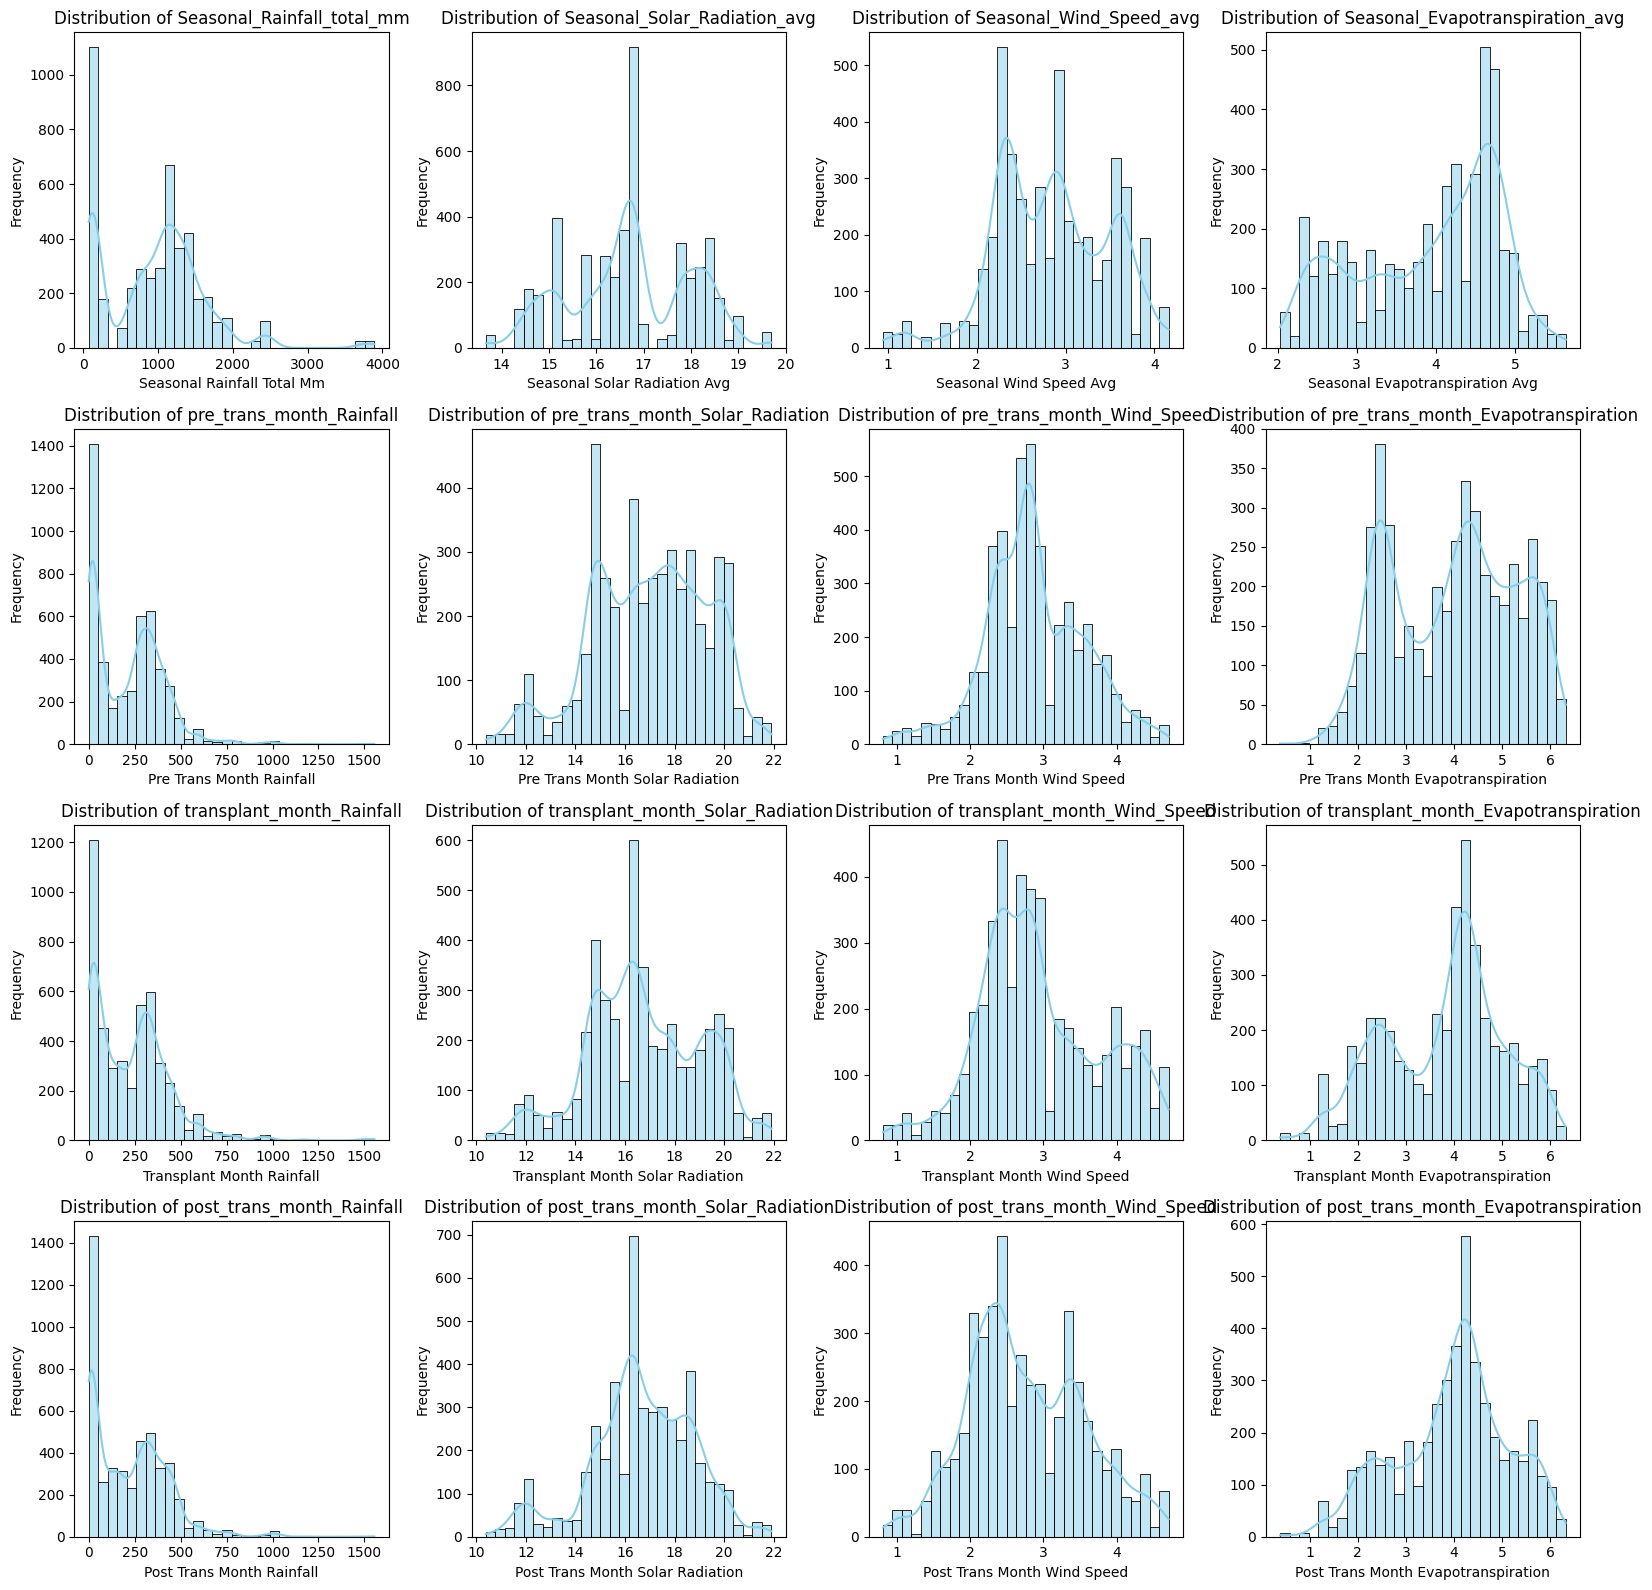

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of all 16 climate-related columns to plot
climate_columns = [
    'Seasonal_Rainfall_total_mm',
    'Seasonal_Solar_Radiation_avg',
    'Seasonal_Wind_Speed_avg',
    'Seasonal_Evapotranspiration_avg',
    'pre_trans_month_Rainfall',
    'pre_trans_month_Solar_Radiation',
    'pre_trans_month_Wind_Speed',
    'pre_trans_month_Evapotranspiration',
    'transplant_month_Rainfall',
    'transplant_month_Solar_Radiation',
    'transplant_month_Wind_Speed',
    'transplant_month_Evapotranspiration',
    'post_trans_month_Rainfall',
    'post_trans_month_Solar_Radiation',
    'post_trans_month_Wind_Speed',
    'post_trans_month_Evapotranspiration'
]

# Set up the matplotlib figure and axes for subplots
# Calculate number of rows and columns for subplots dynamically
num_columns = len(climate_columns)
num_cols_per_row = 4 # You can adjust this for desired layout
num_rows = (num_columns + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(4 * num_cols_per_row, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(climate_columns):
    if col in spas_merged.columns:
        sns.histplot(spas_merged[col].dropna(), kde=True, ax=axes[i], color='skyblue', bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col.replace('_', ' ').title()) # Improve readability of x-label
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_visible(False) # Hide subplot if column doesn't exist

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Correlation Heatmap of Climate Features

To identify potential relationships and dependencies between the various climate features, we will generate a correlation heatmap. This visualization will show us the correlation coefficients between each pair of climate variables.

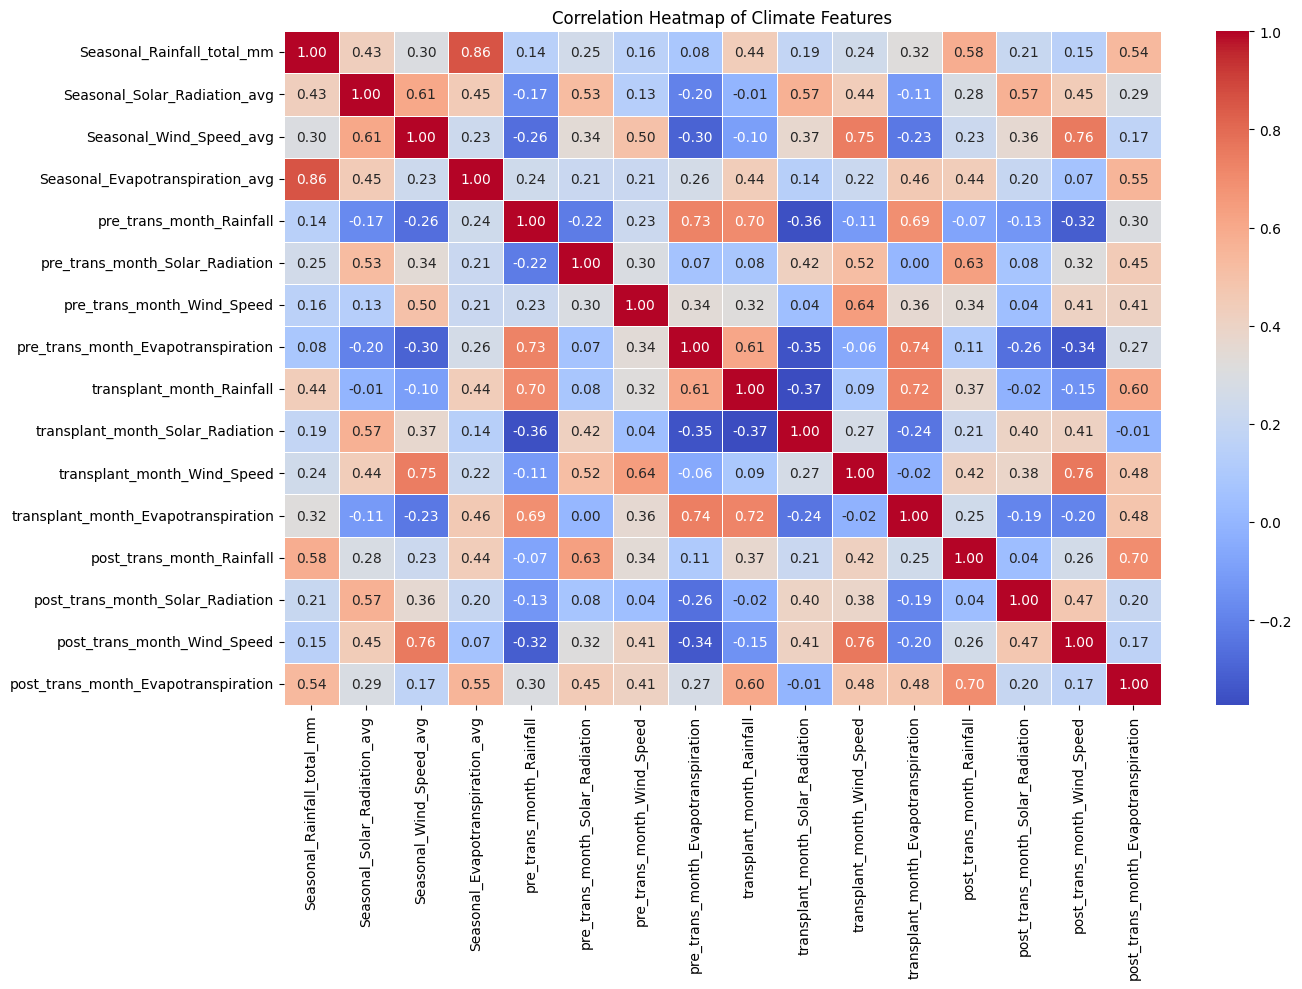

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of all 16 climate-related columns as defined earlier
climate_columns = [
    'Seasonal_Rainfall_total_mm',
    'Seasonal_Solar_Radiation_avg',
    'Seasonal_Wind_Speed_avg',
    'Seasonal_Evapotranspiration_avg',
    'pre_trans_month_Rainfall',
    'pre_trans_month_Solar_Radiation',
    'pre_trans_month_Wind_Speed',
    'pre_trans_month_Evapotranspiration',
    'transplant_month_Rainfall',
    'transplant_month_Solar_Radiation',
    'transplant_month_Wind_Speed',
    'transplant_month_Evapotranspiration',
    'post_trans_month_Rainfall',
    'post_trans_month_Solar_Radiation',
    'post_trans_month_Wind_Speed',
    'post_trans_month_Evapotranspiration'
]

# Filter to include only columns that exist in the DataFrame
existing_climate_columns = [col for col in climate_columns if col in spas_merged.columns]

# Calculate the correlation matrix for the climate features
climate_corr = spas_merged[existing_climate_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(climate_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Climate Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
spas_merged.describe()

,Area,Avg Temp,Max Temp,Min Temp,Avg Humidity,Max Relative Humidity,Min Relative Humidity,Production,Seasonal_Rainfall_total_mm,Seasonal_Solar_Radiation_avg,...,pre_trans_month_Wind_Speed,pre_trans_month_Evapotranspiration,transplant_month_Rainfall,transplant_month_Solar_Radiation,transplant_month_Wind_Speed,transplant_month_Evapotranspiration,post_trans_month_Rainfall,post_trans_month_Solar_Radiation,post_trans_month_Wind_Speed,post_trans_month_Evapotranspiration
count,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4.607000e+03,4607.000000,4607.000000,...,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000,4607.000000
mean,8086.615151,23.878229,30.736271,17.020187,71.597569,61.514217,81.680920,1.443729e+04,943.630803,16.729556,...,2.878254,3.991830,230.371849,16.727256,2.939545,3.815930,221.440341,16.684083,2.764399,3.966942
std,42158.759336,4.722032,5.957123,5.408319,11.246748,12.787288,11.341681,6.563637e+04,669.062617,1.279776,...,0.671182,1.272851,205.780513,2.270340,0.815105,1.226109,199.255475,2.072678,0.794030,1.154186
min,0.000000,11.500000,15.000000,5.000000,35.000000,20.000000,45.000000,0.000000e+00,71.190000,13.668087,...,0.812903,0.386333,0.000000,10.383548,0.812903,0.386333,0.000000,10.383548,0.812903,0.386333
25%,61.000000,20.000000,25.000000,14.500000,67.500000,56.000000,77.500000,1.200000e+02,210.390000,15.861671,...,2.451071,2.678387,48.480000,15.123871,2.383929,2.756129,23.990000,15.552437,2.205667,3.175000
50%,280.000000,25.000000,30.000000,18.000000,72.500000,60.000000,85.000000,7.270000e+02,1000.310000,16.696684,...,2.821000,4.143000,209.170000,16.509677,2.801000,4.097097,196.940000,16.655806,2.693667,4.122903
75%,821.500000,27.500000,35.000000,20.000000,80.000000,70.000000,90.000000,2.881000e+03,1345.640000,17.795226,...,3.336935,5.026774,342.440000,18.549667,3.517097,4.594839,355.690000,18.213226,3.347419,4.719355
max,663734.000000,34.500000,47.000000,27.000000,90.000000,85.000000,100.000000,1.077242e+06,3891.560000,19.700301,...,4.706000,6.320000,1554.050000,21.905667,4.706000,6.320000,1554.050000,21.905667,4.706000,6.320000


### Save Plots and Describe Table

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save the histogram plots
climate_columns = [
    'Seasonal_Rainfall_total_mm',
    'Seasonal_Solar_Radiation_avg',
    'Seasonal_Wind_Speed_avg',
    'Seasonal_Evapotranspiration_avg',
    'pre_trans_month_Rainfall',
    'pre_trans_month_Solar_Radiation',
    'pre_trans_month_Wind_Speed',
    'pre_trans_month_Evapotranspiration',
    'transplant_month_Rainfall',
    'transplant_month_Solar_Radiation',
    'transplant_month_Wind_Speed',
    'transplant_month_Evapotranspiration',
    'post_trans_month_Rainfall',
    'post_trans_month_Solar_Radiation',
    'post_trans_month_Wind_Speed',
    'post_trans_month_Evapotranspiration'
]

num_columns = len(climate_columns)
num_cols_per_row = 4
num_rows = (num_columns + num_cols_per_row - 1) // num_cols_per_row

fig_hist, axes_hist = plt.subplots(num_rows, num_cols_per_row, figsize=(4 * num_cols_per_row, 4 * num_rows))
axes_hist = axes_hist.flatten()

for i, col in enumerate(climate_columns):
    if col in spas_merged.columns:
        sns.histplot(spas_merged[col].dropna(), kde=True, ax=axes_hist[i], color='skyblue', bins=30)
        axes_hist[i].set_title(f'Distribution of {col}')
        axes_hist[i].set_xlabel(col.replace('_', ' ').title())
        axes_hist[i].set_ylabel('Frequency')
    else:
        axes_hist[i].set_visible(False)

for j in range(i + 1, len(axes_hist)):
    axes_hist[j].set_visible(False)

plt.tight_layout()
plt.savefig('climate_feature_histograms.png')
plt.close(fig_hist)
print("Saved climate_feature_histograms.png")

# Save the correlation heatmap
existing_climate_columns = [col for col in climate_columns if col in spas_merged.columns]
climate_corr = spas_merged[existing_climate_columns].corr()

fig_heatmap, ax_heatmap = plt.subplots(figsize=(14, 10))
sns.heatmap(climate_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax_heatmap)
ax_heatmap.set_title('Correlation Heatmap of Climate Features')
ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=90)
ax_heatmap.set_yticklabels(ax_heatmap.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.close(fig_heatmap)
print("Saved correlation_heatmap.png")

# Save the describe output to a file
describe_output = spas_merged.describe().to_string()
with open('spas_merged_description.txt', 'w') as f:
    f.write(describe_output)
print("Saved spas_merged_description.txt")

Saved climate_feature_histograms.png
Saved correlation_heatmap.png
Saved spas_merged_description.txt


You can download the generated files using the following code:

In [ ]:
from google.colab import files

files.download('climate_feature_histograms.png')
files.download('correlation_heatmap.png')
files.download('spas_merged_description.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>